# V3: Investigate Anyang, Daejeon and Jeju

## Goal
Anyang conceded more; Daejeon scored in more matches; Jeju lost less often despite fewer own shots on target and more shots on target faced. These are descriptive findings, not proven mechanisms.

## Setup
Run the notebooks in v1 -> v2 -> v3 -> v4 order. Use a Python environment installed from `requirements.txt`.
The same editable code is in `scripts/v3_focus_teams.py`. No cell crawls a website.

## Context and assumptions
Saved official K League snapshot, audited on 2026-09-30. Before = R1-15; After = R16-30.
Gangwon-Incheon, assigned R22 and played on 2026-09-27, is included once after the break.
Raw CSVs must be supplied locally; see `data/README.md`. Outputs are written to the project, not the Desktop.
Club selection is post-hoc. No causal, weather, rest, xG, or predictive model is fitted.

## Steps


In [1]:
%matplotlib inline

### Setup: resolve paths without a personal Desktop location

In [2]:
from pathlib import Path
import sys

# Scripts resolve from their file; notebooks resolve from their working directory.
start = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
ROOT = next((p for p in (start, *start.parents) if (p / "project_config.py").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from inside the project folder.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from project_config import DATA_DIR, OUTPUT_DIR, TEAM_NAMES, FOCUS_TEAMS, COLORS, save_chart
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

STAGE = "v3"
from pathlib import Path
from statistics import mean, median
from collections import Counter
import csv
import json
import hashlib
import shutil

T = OUTPUT_DIR / STAGE
T.mkdir(parents=True, exist_ok=True)
SOURCE = OUTPUT_DIR / 'v1/01_team_match_dataset.csv'
FOCUS = ['Anyang', 'Daejeon', 'Jeju']
METRICS = ['goals_for', 'goals_against', 'shots', 'shots_on_target',
           'opponent_shots', 'opponent_shots_on_target', 'pass_attempts', 'points']
with SOURCE.open(encoding='utf-8-sig', newline='') as stream:
    rows = list(csv.DictReader(stream))
for row in rows:
    for field in ['round', 'game_id'] + METRICS:
        row[field] = int(row[field])
    row['result'] = 'W' if row['goals_for'] > row['goals_against'] else 'D' if row['goals_for'] == row['goals_against'] else 'L'
assert len(rows) == 360 and len({(r['team'], r['game_id']) for r in rows}) == 360
assert all(r['period'] == ('Before' if r['round'] <= 15 else 'After') for r in rows)
assert all(r['points'] == {'W': 3, 'D': 1, 'L': 0}[r['result']] for r in rows)
matches = [r for r in rows if r['team'] in FOCUS]
assert len(matches) == 90

def subset(team, period):
    return sorted([r for r in matches if r['team'] == team and r['period'] == period], key=lambda r: r['round'])

def save_csv(name, data):
    with (T / name).open('w', encoding='utf-8-sig', newline='') as stream:
        writer = csv.DictWriter(stream, fieldnames=list(data[0]))
        writer.writeheader()
        writer.writerows(data)




### Reconcile mutually exclusive W/D/L outcomes

In [3]:
# Outcome contributions explain arithmetic, not causal mechanisms.
outcomes, outcome_changes, period_summary = [], [], []
for team in FOCUS:
    for period in ['Before', 'After']:
        group = subset(team, period)
        counts = Counter(r['result'] for r in group)
        period_summary.append(dict(team=team, period=period, wins=counts['W'], draws=counts['D'], losses=counts['L'],
            points=sum(r['points'] for r in group), ppg=mean(r['points'] for r in group),
            goals_for=sum(r['goals_for'] for r in group), goals_against=sum(r['goals_against'] for r in group),
            scoreless_matches=sum(r['goals_for']==0 for r in group), clean_sheets=sum(r['goals_against']==0 for r in group)))
        for outcome in ['W', 'D', 'L']:
            part = [r for r in group if r['result']==outcome]
            outcomes.append(dict(team=team, period=period, result=outcome, games=len(part),
                points=sum(r['points'] for r in part), goals_for=sum(r['goals_for'] for r in part),
                goals_against=sum(r['goals_against'] for r in part)))
    for outcome in ['W', 'D', 'L']:
        a, b = [next(r for r in outcomes if r['team']==team and r['period']==p and r['result']==outcome) for p in ['Before','After']]
        outcome_changes.append(dict(team=team, result=outcome, games_change=b['games']-a['games'],
            points_change=b['points']-a['points'], goals_for_change=b['goals_for']-a['goals_for'], goals_against_change=b['goals_against']-a['goals_against']))
save_csv('14_focus_outcome_accounting.csv', outcomes)
save_csv('15_focus_outcome_changes.csv', outcome_changes)
save_csv('16_focus_period_summary.csv', period_summary)




### Compare matches against fixed pre-break medians

In [4]:
# Thresholds identify review groups, not universal performance targets.
cooccurrence = []
for team in FOCUS:
    pre = subset(team, 'Before')
    for attack_metric in ['shots', 'goals_for']:
        attack_cut = median(r[attack_metric] for r in pre)
        ga_cut = median(r['goals_against'] for r in pre)
        for period in ['Before', 'After']:
            for attack_above in [False, True]:
                for ga_above in [False, True]:
                    selected = [r for r in subset(team, period) if
                        (r[attack_metric]>attack_cut)==attack_above and (r['goals_against']>ga_cut)==ga_above]
                    cooccurrence.append(dict(team=team, period=period, attack_metric=attack_metric,
                        attack_pre_median=attack_cut, goals_against_pre_median=ga_cut,
                        attack_above_pre_median=attack_above, goals_against_above_pre_median=ga_above,
                        games=len(selected), rounds=';'.join(str(r['round']) for r in selected),
                        goals_for=sum(r['goals_for'] for r in selected), goals_against=sum(r['goals_against'] for r in selected)))
save_csv('17_focus_match_cooccurrence.csv', cooccurrence)
save_csv('18_focus_match_detail.csv', matches)




### Compare the three club profiles with consistent scales

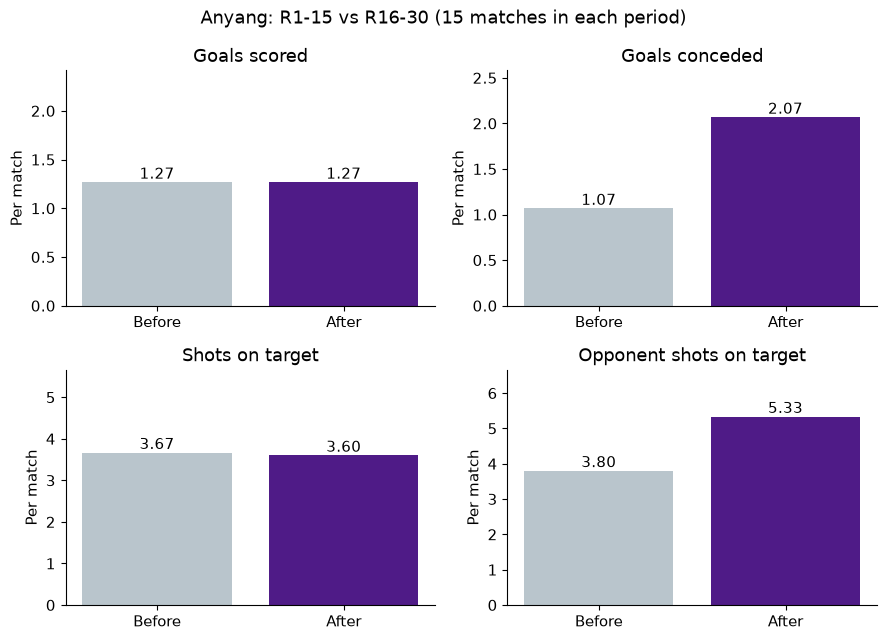

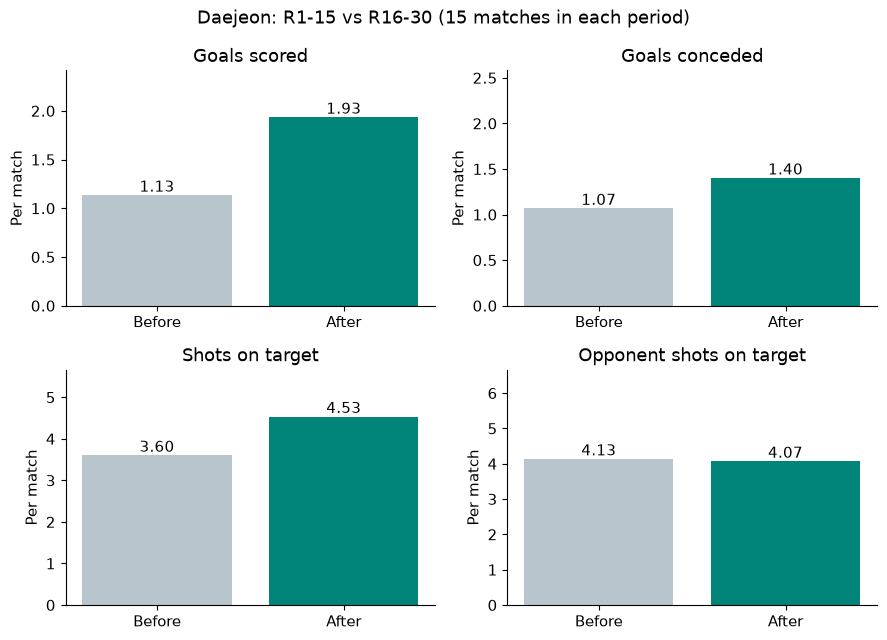

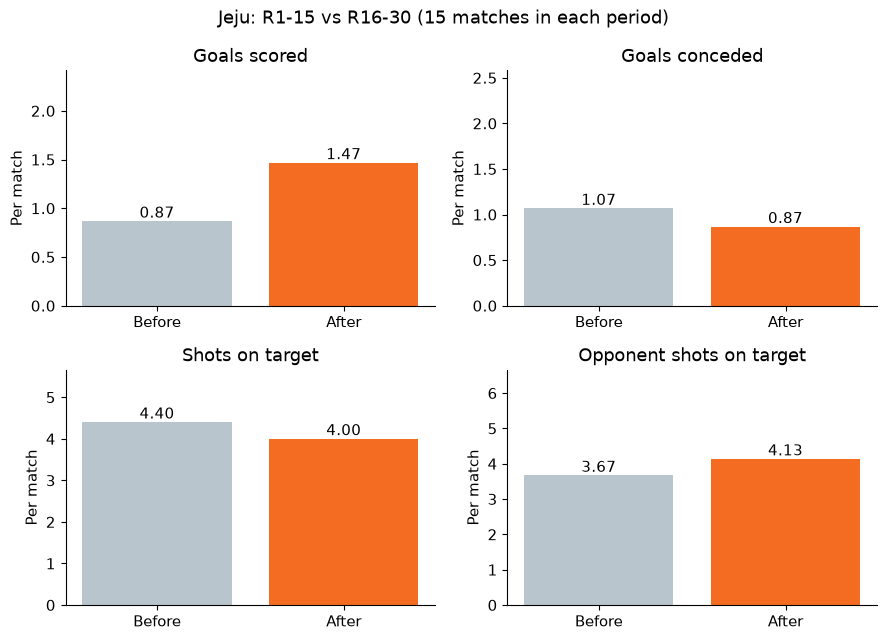

,team,period,wins,draws,losses,points,ppg,goals_for,goals_against,scoreless_matches,clean_sheets
0,Anyang,Before,4,8,3,20,1.333,19,16,3,2
1,Anyang,After,5,3,7,18,1.200,19,31,3,1
2,Daejeon,Before,4,4,7,16,1.067,17,16,7,3
3,Daejeon,After,6,6,3,24,1.600,29,21,2,5
4,Jeju,Before,5,3,7,18,1.200,13,16,4,5
5,Jeju,After,7,7,1,28,1.867,22,13,3,6


In [5]:
from project_config import read_stage
kpis = read_stage("v2", "02_team_period_kpis.csv")
before = kpis.loc[kpis.period == "Before"].set_index("team")
after = kpis.loc[kpis.period == "After"].set_index("team")
panels = [("goals_for_per_match", "Goals scored"), ("goals_against_per_match", "Goals conceded"),
          ("shots_on_target_per_match", "Shots on target"), ("opponent_shots_on_target_per_match", "Opponent shots on target")]
for team in FOCUS:
    fig, axes = plt.subplots(2, 2, figsize=(9, 6.5))
    for ax, (metric, label) in zip(axes.flat, panels):
        values = [before.loc[team, metric], after.loc[team, metric]]
        ax.bar(["Before", "After"], values, color=["#B9C5CC", COLORS[team]])
        ax.set_title(label)
        ax.set_ylabel("Per match")
        ax.set_ylim(0, kpis.loc[kpis.team.isin(FOCUS), metric].max() * 1.25)
        for i, number in enumerate(values):
            ax.text(i, number, f"{number:.2f}", ha="center", va="bottom")
    fig.suptitle(f"{team}: R1-15 vs R16-30 (15 matches in each period)")
    save_chart(fig, T / f"{team.lower()}_profile.png")
display(pd.DataFrame(period_summary).round(3))


## Checks and takeaways
The assertions above must pass. Inspect the saved tables and rendered outputs rather than trusting execution alone.

Anyang conceded more; Daejeon scored in more matches; Jeju lost less often despite fewer own shots on target and more shots on target faced. These are descriptive findings, not proven mechanisms.

## Next steps
Choose one club and explain a result, its supporting evidence, and a counterpoint. Which additional match footage or shot-quality data would distinguish explanations?

**Planned:** revisit the analysis after the 2026 season ends, separating the final-round groups and unequal opponent schedules from the current balanced R1-30 comparison.
